
# Módulo 3 - Visualização de Dados e Storytelling

Este notebook foi organizado para servir como material de aula do **Módulo 3**, articulando explicações conceituais, boas práticas e exemplos prontos com **Matplotlib** e **Seaborn**.

O conteúdo foi planejado em continuidade ao escopo do curso e à estrutura do dataset de municípios brasileiros, com foco em variáveis como:

- `GDP` e `GDP_CAPITA`
- `IDHM`
- `RURAL_URBAN`
- `STATE`
- `GVA_AGROPEC`, `GVA_INDUSTRY`, `GVA_SERVICES`, `GVA_PUBLIC`
- `ESTIMATED_POP`, `COMP_TOT`, `HOTELS`



## 1. Fundamentos da Visualização de Dados

Visualizar dados não é apenas "fazer gráficos bonitos". A visualização é uma forma de **comunicação**. Ela existe para reduzir a dificuldade de interpretação, destacar padrões e apoiar a tomada de decisão.

Quando uma tabela possui milhares de linhas, o cérebro humano tem dificuldade para perceber tendências apenas olhando para números. Um gráfico, por outro lado, permite identificar rapidamente comportamentos como concentração, diferença, crescimento, dispersão e associação entre variáveis.

Antes de construir um gráfico, a pergunta principal deve ser:

> **"O que eu quero descobrir ou comunicar com esses dados?"**

A resposta a essa pergunta orienta a escolha da visualização.



## 2. Storytelling com Dados

Storytelling com dados é a prática de transformar análises em narrativas claras e envolventes, conectando os dados a um contexto e a um objetivo específico. Mais do que apresentar gráficos isolados, o foco está em organizar as informações de forma lógica, destacando os principais insights e conduzindo o público a uma conclusão. Isso torna a comunicação mais eficaz, especialmente para públicos não técnicos.

Uma boa narrativa com dados segue uma estrutura simples: começa com uma pergunta ou problema, apresenta evidências por meio de visualizações e conclui com um insight ou recomendação. O uso estratégico de títulos, destaques visuais e sequência de gráficos ajuda a guiar o olhar e a interpretação do usuário. Dessa forma, o storytelling transforma dados em conhecimento acionável, facilitando a tomada de decisão.



## 2.1. Storytelling com Dados - Como Fazer?

Para construir um bom storytelling com dados, é importante seguir uma estrutura clara e objetiva. O primeiro passo é definir uma pergunta ou problema central, que guiará toda a análise. Em seguida, selecione apenas os dados e gráficos que realmente ajudam a responder essa questão, evitando excesso de informação. Cada visualização deve ter um propósito dentro da narrativa.

Depois, organize os insights em uma sequência lógica: comece apresentando o contexto, evolua para as evidências e finalize com uma conclusão clara. Utilize títulos explicativos, destaques visuais e linguagem simples para conduzir o entendimento do público. O objetivo não é mostrar tudo o que foi analisado, mas sim comunicar de forma direta o que realmente importa e por quê.

- Defina a pergunta principal
- Escolha os dados relevantes
- Selecione os gráficos adequados
- Organize em uma sequência lógica
- Destaque os principais insights
- Conclua com uma mensagem clara



## 2.2. Storytelling com Dados - Exemplo

Neste exemplo, o gráfico “antes” apresenta todos os produtos com o mesmo nível de destaque, o que dificulta a identificação do principal insight. Já no gráfico “depois”, o Produto A passa a ser o foco visual, enquanto os demais aparecem em segundo plano. Além disso, o título, os rótulos e a anotação reforçam a mensagem central de que houve crescimento de 2,5x ao longo dos trimestres. Esse contraste mostra como o storytelling com dados não depende apenas de exibir informações, mas de organizá-las visualmente para comunicar uma conclusão clara.


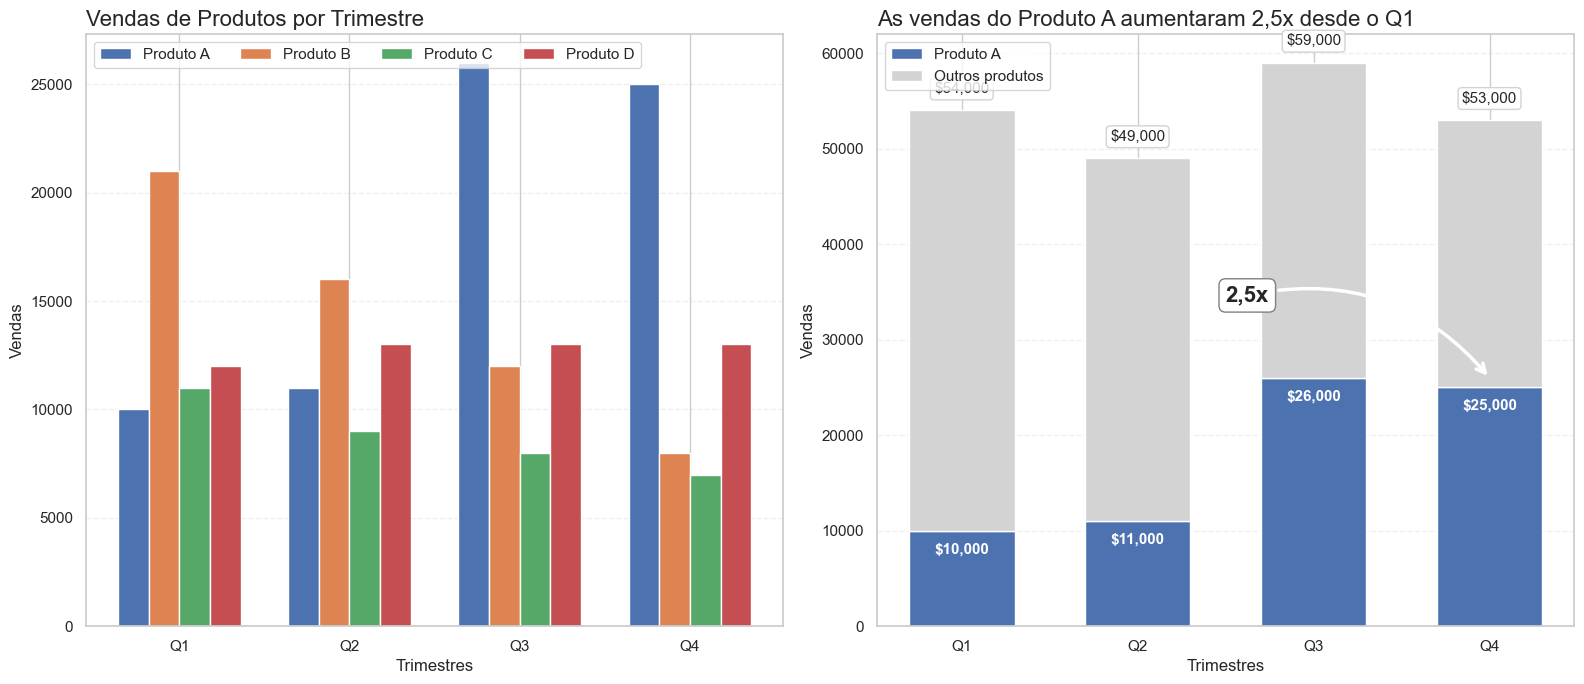

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Dados de exemplo
trimestres = ["Q1", "Q2", "Q3", "Q4"]
produto_a = [10000, 11000, 26000, 25000]
produto_b = [21000, 16000, 12000, 8000]
produto_c = [11000, 9000, 8000, 7000]
produto_d = [12000, 13000, 13000, 13000]

x = np.arange(len(trimestres))
largura = 0.18

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# -------------------------
# ANTES
# -------------------------
ax = axes[0]
ax.bar(x - 1.5*largura, produto_a, width=largura, label="Produto A")
ax.bar(x - 0.5*largura, produto_b, width=largura, label="Produto B")
ax.bar(x + 0.5*largura, produto_c, width=largura, label="Produto C")
ax.bar(x + 1.5*largura, produto_d, width=largura, label="Produto D")

ax.set_title("Vendas de Produtos por Trimestre", fontsize=16, loc="left")
ax.set_xticks(x)
ax.set_xticklabels(trimestres)
ax.set_xlabel("Trimestres")
ax.set_ylabel("Vendas")
ax.legend(ncol=4, frameon=True, loc="upper left")
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

# -------------------------
# DEPOIS
# -------------------------
ax = axes[1]

# Fundo com outros produtos em cinza
outros = np.array(produto_b) + np.array(produto_c) + np.array(produto_d)
ax.bar(x, produto_a, width=0.6, label="Produto A")
ax.bar(x, outros, bottom=produto_a, width=0.6, color="lightgray", label="Outros produtos")

ax.set_title("As vendas do Produto A aumentaram 2,5x desde o Q1", fontsize=16, loc="left")
ax.set_xticks(x)
ax.set_xticklabels(trimestres)
ax.set_xlabel("Trimestres")
ax.set_ylabel("Vendas")
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

# Rótulos do Produto A
for i, v in enumerate(produto_a):
    ax.text(i, v - 1200, f"${v:,.0f}", ha="center", va="top", color="white", fontsize=11, fontweight="bold")

# Totais no topo
totais = np.array(produto_a) + np.array(produto_b) + np.array(produto_c) + np.array(produto_d)
for i, t in enumerate(totais):
    ax.text(i, t + 1500, f"${t:,.0f}", ha="center", va="bottom", fontsize=11,
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="lightgray"))

# Anotação do crescimento
crescimento = produto_a[-1] / produto_a[0]
ax.annotate(
    f"{crescimento:.1f}x".replace(".", ","),
    xy=(3, produto_a[-1] + 1000),
    xytext=(1.5, 34000),
    arrowprops=dict(arrowstyle="->", lw=2.5, connectionstyle="arc3,rad=-0.3"),
    fontsize=16,
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray")
)

# Legenda simplificada
ax.legend(["Produto A", "Outros produtos"], frameon=True, loc="upper left")

plt.tight_layout()
plt.show()


## 3. Gráficos e seus tipos

Os gráficos são ferramentas essenciais na análise de dados, pois permitem transformar informações numéricas em representações visuais mais intuitivas. No entanto, a escolha do tipo de gráfico e a forma como ele é apresentado impactam diretamente na compreensão do público. Um gráfico eficiente não é apenas visualmente bonito, mas sim aquele que comunica uma mensagem clara e facilita a identificação de padrões, relações e tendências.

Em análise de dados, quatro objetivos aparecem com muita frequência:

### 3.1 Comparação
A comparação é usada quando queremos verificar diferenças entre categorias ou grupos.

Exemplos de perguntas:
- Quais municípios possuem maior `GDP_CAPITA`?
- Quais estados concentram mais PIB?
- Onde existem mais hotéis ou empresas?

Gráficos mais comuns:
- gráfico de barras
- gráfico de colunas
- rankings

---

### 3.2 Distribuição
A distribuição mostra como os valores se espalham. Ela ajuda a entender concentração, dispersão, assimetria e valores extremos.

Exemplos de perguntas:
- A maioria dos municípios possui `IDHM` alto ou médio?
- O `GDP_CAPITA` está concentrado em poucos municípios?
- Existem outliers?

Gráficos mais comuns:
- histograma
- boxplot

---

### 3.3 Relação
A relação analisa como duas ou mais variáveis se comportam em conjunto.

Exemplos de perguntas:
- Municípios mais ricos tendem a ter maior `IDHM`?
- O crescimento econômico acompanha o desenvolvimento humano?
- Existe associação entre população e PIB?

Gráficos mais comuns:
- scatterplot
- heatmap de correlação

---

### 3.4 Composição
A composição mostra como um todo está dividido em partes.

Exemplos de perguntas:
- Qual setor representa maior parcela da economia?
- A economia municipal é mais voltada para serviços, indústria, agropecuária ou setor público?

Gráficos mais comuns:
- gráfico de pizza
- barras empilhadas

---

### Ideia central
A escolha do gráfico precisa acompanhar a pergunta analítica. Um gráfico adequado acelera o entendimento; um gráfico inadequado atrapalha a leitura e pode levar a conclusões erradas.



## 4. Bibliotecas práticas: Matplotlib e Seaborn

### 4.1 Matplotlib
O Matplotlib é a biblioteca base de visualização em Python. Com ela, é possível criar gráficos do zero e controlar elementos como:
- tamanho da figura
- eixos
- rótulos
- títulos
- legendas
- grades
- rotação de textos

Aprender Matplotlib é importante porque ajuda o aluno a entender a estrutura fundamental de um gráfico.

### 4.2 Seaborn
O Seaborn é construído sobre o Matplotlib, mas oferece uma interface mais direta para visualizações estatísticas. Ele se integra muito bem com DataFrames do Pandas e facilita a criação de:
- boxplots
- scatterplots
- heatmaps
- histogramas com estilo mais elaborado

Em termos didáticos:
- **Matplotlib** ajuda a entender a construção do gráfico
- **Seaborn** acelera a exploração analítica


In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Altere o nome do arquivo, se necessário.
caminho_dataset = "../datasets/brazilian_cities.csv"

if Path(caminho_dataset).exists():
    df = pd.read_csv(caminho_dataset)
    print("Dataset carregado com sucesso.")
    print(f"Linhas: {df.shape[0]} | Colunas: {df.shape[1]}")
else:
    df = None
    print(
        "Arquivo não encontrado. Coloque o CSV do dataset na mesma pasta do notebook "
        "ou ajuste a variável 'caminho_dataset'."
    )



## 5. Estrutura do dataset utilizada neste módulo

O dataset de municípios brasileiros reúne dezenas de variáveis públicas sobre demografia, desenvolvimento humano, economia, empresas, infraestrutura, mobilidade, turismo e serviços.

Para este módulo, algumas colunas são especialmente úteis:

- `GDP` — Produto Interno Bruto
- `GDP_CAPITA` — PIB per capita
- `IDHM` — Índice de Desenvolvimento Humano Municipal
- `RURAL_URBAN` — tipologia rural/urbana
- `STATE` — estado
- `GVA_AGROPEC`, `GVA_INDUSTRY`, `GVA_SERVICES`, `GVA_PUBLIC` — composição setorial da economia
- `ESTIMATED_POP` — população estimada
- `COMP_TOT` — total de empresas
- `HOTELS` — número de hotéis

A combinação dessas colunas permite construir exemplos ricos e realistas para o ensino de visualização.


In [ ]:

# Verificação inicial das colunas mais usadas no módulo
colunas_modulo = [
    "CITY", "STATE", "GDP", "GDP_CAPITA", "IDHM", "RURAL_URBAN",
    "GVA_AGROPEC", "GVA_INDUSTRY", "GVA_SERVICES", "GVA_PUBLIC",
    "GVA_TOTAL", "ESTIMATED_POP", "COMP_TOT", "HOTELS"
]

if df is not None:
    existentes = [c for c in colunas_modulo if c in df.columns]
    ausentes = [c for c in colunas_modulo if c not in df.columns]

    print("Colunas encontradas:")
    print(existentes)
    print("\nColunas não encontradas:")
    print(ausentes)



# 6. Exemplos práticos de gráficos

Nos exemplos a seguir, cada bloco foi organizado para representar um tipo de objetivo visual:

1. **Comparação**
2. **Distribuição**
3. **Relação**
4. **Composição**

A ideia é que o aluno não apenas reproduza o código, mas também interprete o que cada gráfico mostra.



## 6.1 Comparação — gráfico de barras

Quando o objetivo é comparar valores entre categorias, o gráfico de barras costuma ser a melhor escolha. Neste exemplo, vamos mostrar os municípios com maior `GDP_CAPITA`.

Esse tipo de visualização ajuda a responder perguntas como:
- quais são os maiores valores?
- qual a diferença entre os primeiros colocados?
- existe concentração em certos estados?


In [ ]:
if df is not None:
    
    # Seleciona apenas as colunas necessárias para a análise
    top10_gdp_capita = (
        df[["CITY", "STATE", "GDP_CAPITA"]]
        
        # Remove linhas com valores nulos (evita erros no gráfico)
        .dropna()
        
        # Ordena os municípios do maior para o menor PIB per capita
        .sort_values("GDP_CAPITA", ascending=False)
        
        .head(10)
    )

    # Define o tamanho da figura (largura, altura)
    plt.figure(figsize=(12, 6))
    
    # Cria o gráfico de barras
    sns.barplot(
        data=top10_gdp_capita,
        
        # Eixo X → valores numéricos (PIB per capita)
        x="GDP_CAPITA",
        
        # Eixo Y → categorias (municípios)
        y="CITY",
        
        # Usa cores para diferenciar os estados
        hue="STATE",
        
        # Evita separar barras da mesma categoria (mantém uma barra por município)
        dodge=False,
        
        # Define uma paleta de cores acessível
        palette="Set2"
    )
    
    plt.title("Top 10 municípios com maior PIB per capita")
    plt.xlabel("PIB per capita")
    plt.ylabel("Município")
    
    # Ajusta a posição da legenda
    plt.legend(title="Estado", bbox_to_anchor=(1.02, 1), loc="upper left")
    
    # Ajusta o layout para evitar sobreposição de elementos
    plt.tight_layout()
    plt.show()


### Interpretação
Esse gráfico é útil para mostrar **comparação direta**. Como os valores estão ordenados, a leitura fica rápida. O uso de cor por estado adiciona contexto, sem comprometer a simplicidade.

O gráfico evidencia uma forte concentração do PIB per capita em municípios com atividades econômicas altamente especializadas, como polos industriais e energéticos. Destacam-se cidades como Paulínia (SP) e Selvíria (MS), cujos altos valores não necessariamente refletem maior qualidade de vida, mas sim uma elevada produção econômica em relação à população. Além disso, observa-se que esse padrão não está restrito a uma única região do país, mas sim associado à presença de setores econômicos específicos. Portanto, o PIB per capita deve ser analisado com cautela, pois pode ocultar desigualdades internas e não representar fielmente o bem-estar da população.



## 6.2 Distribuição — histograma

A distribuição serve para entender como os valores estão espalhados. Neste caso, vamos observar o comportamento do `IDHM` nos municípios.

Perguntas possíveis:
- A maioria dos municípios se concentra em faixas altas ou médias?
- Os dados são muito dispersos?
- Há valores extremos?


In [ ]:

if df is not None:
    plt.figure(figsize=(12, 6))
    sns.histplot(df["IDHM"].dropna(), bins=30, kde=True)
    plt.title("Distribuição do IDHM nos municípios brasileiros")
    plt.xlabel("IDHM")
    plt.ylabel("Quantidade de municípios")
    plt.tight_layout()
    plt.show()



### Interpretação
O histograma permite ver a concentração dos valores. A curva ajuda a perceber a forma geral da distribuição. Esse gráfico é excelente para discutir desigualdade, concentração e dispersão.

A distribuição do IDHM nos municípios brasileiros revela que a maior parte das cidades está concentrada na faixa intermediária, entre aproximadamente 0,55 e 0,75, indicando um nível médio de desenvolvimento humano predominante no país. Essa concentração sugere que, embora o Brasil tenha avançado em indicadores básicos, ainda enfrenta dificuldades para elevar grande parte de seus municípios a patamares mais altos de desenvolvimento. A presença reduzida de municípios com IDHM muito baixo indica algum progresso estrutural, enquanto a menor frequência de valores elevados (acima de 0,80) evidencia que o desenvolvimento mais avançado permanece restrito a um grupo limitado de cidades.

Ao relacionar esse padrão com o gráfico de PIB per capita, observa-se que altos níveis de produção econômica não necessariamente se traduzem em melhores condições de vida para a população. Municípios com PIB per capita elevado, muitas vezes impulsionados por atividades industriais ou energéticas específicas, podem não apresentar IDHM igualmente alto, reforçando que crescimento econômico isolado não garante desenvolvimento humano. Dessa forma, a análise conjunta dos indicadores destaca a importância de considerar múltiplas dimensões — como educação, renda e longevidade — para compreender de forma mais completa a realidade socioeconômica dos municípios brasileiros.



## 6.3 Distribuição — boxplot

O boxplot é muito útil quando queremos comparar a distribuição de uma variável entre categorias. Aqui, vamos comparar o `IDHM` por `RURAL_URBAN`.


In [ ]:
# Verifica se o DataFrame existe e se a coluna necessária está presente
if df is not None and "RURAL_URBAN" in df.columns:
    
    # Criamos uma cópia para não alterar o DataFrame original
    df_plot = df.copy()
    
    # Removemos valores nulos na coluna de tipologia
    df_plot = df_plot[df_plot["RURAL_URBAN"].notna()]
    
    # Removemos categorias inválidas
    # "0" → valor incorreto vindo do dataset
    # "Sem classificação" → não representa uma tipologia útil para análise
    df_plot = df_plot[
        (df_plot["RURAL_URBAN"] != "0") &
        (df_plot["RURAL_URBAN"] != "Sem classificação")
    ]
    
    # Removendo IDHM nulo
    df_plot = df_plot[df_plot["IDHM"].notna()]
    
    # Criação do gráfico
    plt.figure(figsize=(10, 6))
    
    sns.boxplot(
        data=df_plot,
        x="RURAL_URBAN",
        y="IDHM",
        palette="Set2"
    )
    
    # Títulos e rótulos
    plt.title("Distribuição do IDHM por tipologia rural/urbana")
    plt.xlabel("Tipologia")
    plt.ylabel("IDHM")
    
    # Rotaciona os labels para melhor leitura
    plt.xticks(rotation=20)
    
    # Ajusta layout para evitar cortes
    plt.tight_layout()
    
    # Exibe o gráfico
    plt.show()


### Interpretação
O boxplot mostra:
- mediana
- quartis
- dispersão
- possíveis outliers

Ele é muito adequado para discutir desigualdades entre grupos e complementar o histograma.

No exemplo, o boxplot evidencia diferenças claras no nível de desenvolvimento humano entre as tipologias territoriais. Municípios classificados como urbanos apresentam, em geral, medianas de IDHM mais elevadas e menor dispersão, indicando maior consistência nos níveis de desenvolvimento. Em contrapartida, tipologias rurais, especialmente as remotas, concentram valores mais baixos e maior variabilidade, sugerindo maior desigualdade interna e menor acesso a serviços essenciais. As tipologias intermediárias ocupam uma posição de transição, com resultados entre os dois extremos, refletindo características híbridas entre o urbano e o rural.

Além disso, a presença de outliers — incluindo valores significativamente baixos — reforça a existência de disparidades acentuadas dentro de algumas categorias, principalmente nas áreas rurais. Esse padrão indica que o desenvolvimento humano no Brasil está fortemente associado ao grau de urbanização e à acessibilidade territorial. Em conjunto com os outros gráficos, o resultado sugere que fatores estruturais, como infraestrutura, acesso à educação e serviços de saúde, desempenham papel mais determinante no IDHM do que apenas indicadores econômicos isolados, evidenciando a complexidade das desigualdades regionais no país.



## 6.4 Relação — scatterplot

Quando queremos verificar se duas variáveis se comportam juntas, o scatterplot é uma excelente escolha. Neste exemplo, a pergunta é:

> Municípios com maior `GDP_CAPITA` tendem a apresentar maior `IDHM`?


In [ ]:

if df_plot is not None:
    plt.figure(figsize=(12, 6))
    sns.scatterplot(
        data=df_plot,
        x="GDP_CAPITA",
        y="IDHM",
        hue="RURAL_URBAN" if "RURAL_URBAN" in df_plot.columns else None,
        alpha=0.7,
        palette="Set2"
    )
    plt.title("Relação entre PIB per capita e IDHM")
    plt.xlabel("PIB per capita")
    plt.ylabel("IDHM")
    plt.tight_layout()
    plt.show()



### Interpretação
O scatterplot permite observar tendências, aglomerações e pontos fora do padrão. Se os pontos tendem a subir da esquerda para a direita, isso sugere associação positiva.

O gráfico indica uma relação positiva entre PIB per capita e IDHM, ou seja, municípios com maior produção econômica por habitante tendem, em média, a apresentar melhores níveis de desenvolvimento humano. No entanto, essa relação não é linear nem uniforme: observa-se uma grande concentração de municípios com PIB per capita relativamente baixo (até cerca de 50 mil) e IDHM variando significativamente, o que evidencia que aumentos iniciais de renda estão associados a ganhos mais perceptíveis em desenvolvimento. À medida que o PIB per capita cresce, os valores de IDHM passam a se estabilizar, sugerindo um possível efeito de saturação, onde ganhos econômicos adicionais geram impactos menores nos indicadores sociais.

Além disso, a dispersão dos pontos e a presença de municípios com alto PIB per capita, mas IDHM apenas moderado, reforçam que o crescimento econômico isolado não garante melhoria proporcional na qualidade de vida. A diferenciação por tipologia territorial também revela que municípios urbanos tendem a ocupar faixas mais altas de IDHM, enquanto áreas rurais — especialmente remotas — concentram maior variabilidade e níveis mais baixos. Assim, o gráfico evidencia que o desenvolvimento humano depende de múltiplos fatores estruturais, como acesso a serviços, educação e infraestrutura, e não apenas da capacidade econômica local.

### Atenção ética
Mesmo que haja associação visual, isso **não prova causalidade**. O gráfico mostra relação, não causa.



## 6.5 Relação entre múltiplas variáveis — heatmap de correlação

O heatmap resume correlações entre várias variáveis em uma única visualização. É um recurso muito útil na exploração inicial do dataset.


In [ ]:

if df is not None:
    colunas_corr = [
        "GDP",
        "GDP_CAPITA",
        "IDHM",
        "GVA_TOTAL",
        "ESTIMATED_POP",
        "COMP_TOT",
        "HOTELS"
    ]
    colunas_corr = [c for c in colunas_corr if c in df.columns]

    corr = df[colunas_corr].corr(numeric_only=True)

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Mapa de correlação entre variáveis selecionadas")
    plt.tight_layout()
    plt.show()

    corr



### Interpretação
O heatmap facilita a leitura de associações:
- valores próximos de **1** indicam correlação positiva forte
- valores próximos de **-1** indicam correlação negativa forte
- valores próximos de **0** indicam pouca associação linear

O mapa de correlação evidencia que variáveis econômicas estruturais, como PIB (GDP), valor adicionado total (GVA_TOTAL), população estimada (ESTIMATED_POP) e número de empresas (COMP_TOT), apresentam correlações extremamente altas entre si, próximas de 1. Isso indica que esses indicadores crescem de forma conjunta e estão fortemente associados ao porte econômico e populacional dos municípios. Em outras palavras, cidades maiores tendem a concentrar mais atividade econômica, mais empresas e maior produção total, o que revela um padrão estrutural esperado em sistemas urbanos e regionais.

Por outro lado, o IDHM apresenta correlações apenas moderadas ou fracas com a maioria dessas variáveis, com destaque para uma relação mais relevante com o PIB per capita (≈ 0,47). Isso reforça que o desenvolvimento humano não depende diretamente do volume total de riqueza, mas sim de como essa riqueza é distribuída e convertida em qualidade de vida. Assim, o gráfico confirma que crescimento econômico e desenvolvimento humano são dimensões relacionadas, porém distintas, exigindo análises complementares para uma compreensão mais completa das desigualdades entre os municípios.


## 6.6 Composição — gráfico de pizza

Quando queremos mostrar a participação de cada parte em um todo, uma das opções é o gráfico de pizza. Neste exemplo, vamos olhar a composição média da economia dos municípios com base em quatro setores.


In [ ]:

if df is not None:
    colunas_setores = ["GVA_AGROPEC", "GVA_INDUSTRY", "GVA_SERVICES", "GVA_PUBLIC"]
    colunas_setores = [c for c in colunas_setores if c in df.columns]

    medias_setores = df[colunas_setores].mean()

    plt.figure(figsize=(8, 8))
    plt.pie(
        medias_setores,
        labels=["Agropecuária", "Indústria", "Serviços", "Setor público"][:len(medias_setores)],
        autopct="%1.1f%%",
        startangle=90
    )
    plt.title("Composição média da economia dos municípios por setor")
    plt.tight_layout()
    plt.show()

    medias_setores



### Interpretação
Esse gráfico mostra como o valor adicionado médio se distribui entre os setores. É útil quando existem poucas categorias.

O gráfico evidencia que a economia dos municípios brasileiros é fortemente concentrada no setor de serviços, que representa mais da metade da composição média (≈ 55,7%). Esse predomínio indica um padrão típico de economias mais urbanizadas, onde atividades como comércio, transporte, educação e saúde desempenham papel central na geração de valor. Em seguida, a indústria aparece com cerca de 21,2%, demonstrando relevância, mas ainda distante do setor de serviços, enquanto o setor público (≈ 17,4%) também possui participação significativa, refletindo o peso da administração pública em muitos municípios. Já a agropecuária, com aproximadamente 5,7%, apresenta menor participação média, embora possa ser dominante em localidades específicas.

Essa distribuição revela uma economia relativamente diversificada, porém com forte dependência do setor terciário, o que pode indicar maior dinamismo em áreas urbanas, mas também possível vulnerabilidade a oscilações nesse segmento. Além disso, a participação relevante do setor público sugere que, em muitos municípios, a atividade econômica está parcialmente sustentada por gastos governamentais. Em conjunto com os demais gráficos, esse resultado reforça que o desenvolvimento econômico e humano está mais associado à estrutura e diversificação das atividades do que apenas ao volume total de produção, evidenciando a importância de políticas que promovam equilíbrio entre os setores e desenvolvimento sustentável.

O gráfico de pizza deve ser usado com cuidado. Quando há muitas categorias ou quando queremos comparar grupos diferentes, barras empilhadas costumam funcionar melhor.



## 6.7 Composição comparativa — barras empilhadas por estado

Aqui, vamos mostrar a composição média dos setores econômicos por estado. Essa abordagem costuma ser mais útil que a pizza quando o objetivo é comparar vários grupos ao mesmo tempo.


In [ ]:
if df is not None and "STATE" in df.columns:
    
    # Lista das colunas de setores econômicos que queremos analisar
    colunas_setores = ["GVA_AGROPEC", "GVA_INDUSTRY", "GVA_SERVICES", "GVA_PUBLIC"]
    
    # Mantém apenas as colunas que realmente existem no dataset
    colunas_setores = [c for c in colunas_setores if c in df.columns]
    
    # Cria uma cópia para não modificar o DataFrame original
    df_plot = df.copy()
    
    # Remove linhas sem estado
    df_plot = df_plot[df_plot["STATE"].notna()]
    
    # Remove linhas onde todos os setores estão nulos
    df_plot = df_plot.dropna(subset=colunas_setores, how="all")
    
    # Agrupa por estado e calcula a média dos valores adicionados por setor
    setores_estado = df_plot.groupby("STATE")[colunas_setores].mean()
    
    # Seleciona apenas os 10 primeiros estados em ordem alfabética
    setores_estado = setores_estado.head(10)
    
    # Converte os valores absolutos em participação percentual
    setores_estado_percentual = setores_estado.div(setores_estado.sum(axis=1), axis=0) * 100
    
    # Cria o gráfico de barras empilhadas
    setores_estado_percentual.plot(
        kind="bar",
        stacked=True,
        figsize=(12, 6)
    )
    
    plt.title("Composição percentual média do valor adicionado por setor em estados selecionados")
    plt.xlabel("Estado")
    plt.ylabel("Participação percentual (%)")
    
    # Posiciona a legenda fora do gráfico para melhorar a leitura
    plt.legend(title="Setor", bbox_to_anchor=(1.02, 1), loc="upper left")
    
    # Ajusta o layout para evitar cortes
    plt.tight_layout()
    
    plt.show()
    
    display(setores_estado_percentual.head())


O gráfico mostra que, embora o setor de serviços seja predominante em todos os estados, há diferenças importantes na estrutura econômica entre eles. Estados como DF, ES e GO apresentam forte concentração em serviços, indicando economias mais urbanizadas e orientadas ao setor terciário. Por outro lado, alguns estados se destacam por características específicas: o AM (Amazonas) possui uma participação industrial elevada, refletindo a influência da Zona Franca de Manaus, enquanto o AP (Amapá) apresenta alta dependência do setor público, sugerindo menor dinamismo econômico privado. Já estados como BA e CE mostram uma distribuição mais equilibrada entre indústria e serviços, indicando maior diversificação econômica.

Além disso, a agropecuária, apesar de presente em todos os estados, possui participação relativamente menor na composição geral, sendo mais relevante em estados como AC, AL e GO. Esse padrão reforça que o desenvolvimento econômico regional no Brasil é heterogêneo e fortemente influenciado por fatores estruturais e históricos. Em conjunto com os demais gráficos, percebe-se que não apenas o volume econômico, mas também a composição setorial da economia desempenha papel fundamental no desenvolvimento dos municípios, evidenciando que estados mais diversificados tendem a apresentar maior resiliência e potencial de crescimento sustentável.


## 7. Boas práticas de comunicação visual

Ao criar qualquer um dos gráficos anteriores, é importante seguir algumas regras:

### Títulos informativos
Evite títulos vagos. Prefira textos que expliquem o conteúdo da visualização.

### Eixos nomeados
O leitor precisa saber o que cada eixo representa.

### Cores com propósito
As cores devem guiar a leitura. Não devem ser usadas apenas por decoração.

### Legendas claras
Se existe categorização por cor, a legenda precisa estar clara e posicionada de forma legível.

### Simplicidade
Se um elemento não ajuda a entender o gráfico, ele provavelmente pode ser removido.



## 8. Carga Cognitiva: menos é mais na comunicação visual

**Carga cognitiva** é o esforço mental necessário para entender uma informação.

Quando um gráfico tem excesso de elementos — muitas cores, muitas categorias, títulos vagos, poluição visual ou ausência de foco — o leitor precisa gastar mais energia para compreender a mensagem. Isso dificulta a análise e reduz o impacto da visualização.

### Como reduzir a carga cognitiva
- mostrar apenas o necessário
- usar títulos claros
- evitar excesso de categorias
- usar cores com propósito
- remover elementos que não ajudam na leitura
- ordenar dados quando fizer sentido

### Exemplo prático
Ao invés de mostrar centenas de municípios em um único gráfico de barras, é mais didático mostrar um **Top 10** ou filtrar por estado.


## 9. Comunicação visual e ética

Visualização de dados também é uma questão de responsabilidade. Um gráfico pode informar corretamente, mas também pode induzir interpretações equivocadas quando é construído de forma ruim.

### Como evitar gráficos enganosos
- não manipular escalas para exagerar diferenças
- deixar claro quando existe filtragem
- não omitir contexto relevante
- usar o tipo de gráfico adequado
- evitar excesso de destaque visual sem motivo
- lembrar que correlação não significa causalidade

### Regra de ouro
Se o gráfico pode levar alguém a uma conclusão errada, ele precisa ser ajustado.

### Títulos informativos
Um bom título deve dizer:
- o que está sendo analisado
- qual o contexto
- qual o recorte, quando necessário

Exemplos:
- **Ruim:** "PIB"
- **Melhor:** "Top 10 municípios com maior PIB per capita"

### Paletas de cores acessíveis
As cores devem ajudar a leitura, não atrapalhar. É recomendável:
- usar poucas cores
- manter contraste adequado
- evitar combinações problemáticas, como vermelho e verde sem necessidade
- preferir paletas acessíveis, como `viridis`, `Set2`, `coolwarm` e `colorblind`

> Título claro e cor bem escolhida aumentam muito a qualidade de um gráfico.



## 10. Exercícios sugeridos

1. Crie um gráfico de barras mostrando a **distribuição média das faixas etárias**.
2. Crie um **scatterplot** entre `AREA` e `ESTIMATED_POP`.
3. Crie uma nova coluna `DENSIDADE = ESTIMATED_POP / AREA` e faça um **histograma** dessa nova variável.
4. Utilizando, `RURAL_URBAN` e `IDHM`, crie um **boxplot** comparando o IDHM entre áreas urbanas e rurais
5. Escolha os setores abaixo e crie um gráfico de **barras empilhadas** mostrando a composição média desses setores por estado.

- `COMP_A`
- `COMP_G`
- `COMP_K`
- `COMP_M`


## Conclusão do módulo

Neste módulo, a visualização de dados foi tratada como uma ponte entre **análise** e **comunicação**. O aluno aprendeu que não basta gerar gráficos: é preciso entender o tipo de pergunta envolvida, escolher a visualização apropriada e apresentar o resultado com clareza.

Os quatro objetivos principais — **comparação, distribuição, relação e composição** — formam a base da leitura visual de dados. Com o apoio de **Matplotlib** e **Seaborn**, torna-se possível criar gráficos informativos, esteticamente organizados e úteis para interpretação.

Além disso, o módulo reforça que toda visualização carrega uma dimensão ética. Escalas, cores, recortes e títulos influenciam a forma como a informação será compreendida. Por isso, comunicar com responsabilidade é parte essencial do trabalho com dados.